# 99_explore — 실험별 시각화 탐색 도구

**목적**: `final/results/*.pkl` 의 임의 실험을 입력만 바꿔 시각화 탐색.

## 모듈형 함수

| 함수 | 입력 | 출력 |
|---|---|---|
| `load_result(name)` | 실험명 | 결과 dict |
| `metrics_summary(names, period)` | 실험명 list | metrics 표 |
| `plot_single(name, period)` | 1개 실험명 | 종합 패널 (6개 차트) |
| `plot_compare(names, period)` | 여러 실험명 | 비교 차트 (4개) |
| `plot_omega(name, period)` | EWMA 실험명 | omega·view_e 진단 (4개) |
| `plot_weights(name, n_top)` | 실험명, top n | 가중치 heatmap |

## 사용법

맨 아래 "사용 예시" 셀의 `name` 변수만 바꾸면 됩니다.

In [1]:
# ─── 임포트 + 한글 폰트 설정 ────────────────────────────────────────
import pickle
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import koreanize_matplotlib  # noqa
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

import sys
sys.path.insert(0, str(Path.cwd()))
from bl_functions import compute_metrics

# ─── 경로 ────────────────────────────────────────────────────────────
BASE_DIR    = Path.cwd()
DATA_DIR    = BASE_DIR / 'data'
RESULTS_DIR = BASE_DIR / 'results'

print(f'결과 폴더: {RESULTS_DIR}')
print(f'  pkl 갯수: {len(list(RESULTS_DIR.glob("*.pkl")))}개')

결과 폴더: c:\Users\gorhk\최종 프로젝트\finance_project\final\results
  pkl 갯수: 165개


In [2]:
# ─── 공통 데이터 로드 (rf, spy) ─────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])
rf_series  = panel['rf_1m'].groupby(level='date').first()
spy_series = panel['spy_ret'].groupby(level='date').first()


def list_results():
    """results/ 폴더의 모든 pkl 이름 반환 (확장자 제외, 정렬)."""
    return sorted([p.stem for p in RESULTS_DIR.glob('*.pkl')])


def load_result(name):
    """단일 실험 pkl 로드."""
    path = RESULTS_DIR / f'{name}.pkl'
    if not path.exists():
        raise FileNotFoundError(f'{path} 없음. list_results() 로 확인.')
    with open(path, 'rb') as f:
        return pickle.load(f)


def get_period_data(res, period):
    """기간 trim 한 ret/rf/spy 시리즈 반환."""
    start, end = period
    ret = res['ret'].loc[start:end]
    rf  = rf_series.loc[start:end]
    spy = spy_series.loc[start:end]
    return ret, rf, spy


print(f'로드 가능한 실험: {len(list_results())}개')
print(f'예: {list_results()[:5]}')

로드 가능한 실험: 165개
예: ['baseline', 'baseline_q55', 'baseline_q64', 'baseline_q70', 'capm_no_bl']


In [3]:
# ─── 모듈 1: metrics 표 ─────────────────────────────────────────────
def metrics_summary(names, period=('2010-01', '2024-12')):
    """여러 실험의 metrics 표 (DataFrame 반환).

    Parameters
    ----------
    names  : list[str]   실험명 리스트
    period : (start, end) 분석 기간
    """
    rows = []
    for name in names:
        try:
            res = load_result(name)
        except FileNotFoundError:
            rows.append({'name': name, 'note': 'pkl 없음'})
            continue
        ret, rf, spy = get_period_data(res, period)
        if len(ret) == 0:
            rows.append({'name': name, 'note': '데이터 없음'})
            continue
        m = compute_metrics(ret, rf, label=name, mkt_ret=spy)
        rows.append({
            'name'    : name,
            'n_month' : len(ret),
            'Sharpe'  : m['sharpe'],
            'Sortino' : m['sortino'],
            'CAGR'    : m['cagr'],
            'Vol'     : m['vol'],
            'MDD'     : m['mdd'],
            'Calmar'  : m['calmar'],
            'Beta'    : m['beta'],
            'Alpha'   : m['alpha'],
            'WinRate' : m['win_rate'],
        })
    df = pd.DataFrame(rows)
    return df


# ─── 사용 예시 ─────────────────────────────────────────────────────
summary = metrics_summary(['baseline', 'p_lstm_vol_mcap_ewma_lo', 'p_lstm_mcap_ewma_lo'])
summary

,name,n_month,Sharpe,Sortino,CAGR,Vol,MDD,Calmar,Beta,Alpha,WinRate,note
0,baseline,180.0,1.106,1.726,0.1355,0.1098,-0.1303,1.04,-0.136,0.1395,0.678,NaN
1,p_lstm_vol_mcap_ewma_lo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pkl 없음
2,p_lstm_mcap_ewma_lo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pkl 없음


In [4]:
# ─── 모듈 2: 단일 실험 종합 시각화 (6 panels) ───────────────────────
def plot_single(name, period=('2010-01', '2024-12'), figsize=(15, 10)):
    """단일 실험의 종합 진단 패널.

    1. 누적수익률 (vs SPY)
    2. Drawdown 곡선
    3. 월별 수익률 히스토그램
    4. 12개월 rolling Sharpe
    5. 포트폴리오 구성 (eff_n + top10_share)
    6. 거래비용·turnover
    """
    res = load_result(name)
    ret, rf, spy = get_period_data(res, period)
    cfg = res['config']

    fig, axes = plt.subplots(3, 2, figsize=figsize)
    fig.suptitle(f'[{name}]  기간 {ret.index[0].date()} ~ {ret.index[-1].date()}  ({len(ret)}개월)',
                 fontsize=13, fontweight='bold')

    # 1. 누적수익률 vs SPY
    ax = axes[0, 0]
    cum_ret = (1 + ret).cumprod()
    cum_spy = (1 + spy.fillna(0)).cumprod()
    ax.plot(cum_ret.index, cum_ret.values, label=name, color='C0', linewidth=1.5)
    ax.plot(cum_spy.index, cum_spy.values, label='SPY', color='gray', linestyle='--', linewidth=1.2)
    ax.set_title('누적수익률 (1.0 시작)')
    ax.set_yscale('log')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

    # 2. Drawdown
    ax = axes[0, 1]
    dd = (cum_ret - cum_ret.cummax()) / cum_ret.cummax()
    ax.fill_between(dd.index, dd.values, 0, color='C3', alpha=0.4)
    ax.plot(dd.index, dd.values, color='C3', linewidth=1.0)
    ax.set_title(f'Drawdown (MDD = {dd.min()*100:.2f}%)')
    ax.set_ylabel('손실률')
    ax.grid(True, alpha=0.3)

    # 3. 월별 수익률 분포
    ax = axes[1, 0]
    ax.hist(ret.values * 100, bins=40, color='C0', alpha=0.7, edgecolor='black', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline(ret.mean() * 100, color='C3', linestyle='--', linewidth=1.0,
               label=f'평균 {ret.mean()*100:.2f}%')
    ax.set_title('월별 수익률 분포 (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # 4. 12개월 rolling Sharpe
    ax = axes[1, 1]
    excess = ret - rf.fillna(0)
    rolling_sharpe = excess.rolling(12).mean() / excess.rolling(12).std() * np.sqrt(12)
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, color='C2', linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.axhline(rolling_sharpe.mean(), color='C3', linestyle='--', linewidth=0.8,
               label=f'평균 {rolling_sharpe.mean():.2f}')
    ax.set_title('12개월 rolling Sharpe')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # 5. 포트폴리오 구성: effective N
    ax = axes[2, 0]
    comp = res['comp'].loc[period[0]:period[1]]
    if 'eff_n' in comp.columns:
        ax.plot(comp.index, comp['eff_n'].values, color='C0', linewidth=1.0, label='effective N')
        ax.set_ylabel('eff_n', color='C0')
        ax2 = ax.twinx()
        ax2.plot(comp.index, comp['top10_share'].values * 100, color='C1', linewidth=1.0, label='top10 share')
        ax2.set_ylabel('top10 share (%)', color='C1')
        ax.set_title(f'포트폴리오 분산도 (eff_n 평균 {comp["eff_n"].mean():.0f})')
    ax.grid(True, alpha=0.3)

    # 6. 거래비용·turnover
    ax = axes[2, 1]
    if 'turnover' in comp.columns:
        ax.bar(comp.index, comp['turnover'].values, color='C0', alpha=0.6, width=20)
        ax.set_ylabel('turnover')
        ax.set_title(f'월별 turnover (평균 {comp["turnover"].mean():.2f}, '
                     f'tc 비용 누적 {comp["tc_cost"].sum()*100:.2f}%)')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 텍스트 요약 — config + metrics
    print(f'\n[Config]')
    for k, v in cfg.items():
        if k in ('lstm_pred_path', 'name'):
            continue
        print(f'  {k:<15} = {v}')
    m = compute_metrics(ret, rf, label=name, mkt_ret=spy)
    print(f'\n[Metrics]')
    print(f'  Sharpe   = {m["sharpe"]:.3f}')
    print(f'  Sortino  = {m["sortino"]:.3f}')
    print(f'  CAGR     = {m["cagr"]*100:.2f}%')
    print(f'  Vol      = {m["vol"]*100:.2f}%')
    print(f'  MDD      = {m["mdd"]*100:.2f}%')
    print(f'  Calmar   = {m["calmar"]:.3f}')
    print(f'  Beta     = {m["beta"]:.3f}')
    print(f'  Alpha    = {m["alpha"]*100:.2f}%')
    print(f'  WinRate  = {m["win_rate"]*100:.1f}%')

In [5]:
# ─── 모듈 3: 여러 실험 비교 시각화 ──────────────────────────────────
def plot_compare(names, period=('2010-01', '2024-12'),
                 include_spy=True, figsize=(15, 10)):
    """여러 실험 비교 패널 — 4 panels.

    1. 누적수익률 비교
    2. Drawdown 비교
    3. Sharpe·CAGR·MDD 막대
    4. 12M rolling Sharpe 비교
    """
    rets = {}
    for name in names:
        try:
            res = load_result(name)
            r, _, _ = get_period_data(res, period)
            rets[name] = r
        except FileNotFoundError:
            print(f'⚠ {name} 없음 — 건너뜀')
    if not rets:
        print('표시할 실험 없음')
        return

    spy = spy_series.loc[period[0]:period[1]].fillna(0)

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f'실험 비교 ({len(rets)}개)  기간 {period[0]} ~ {period[1]}',
                 fontsize=13, fontweight='bold')

    # 색상 cycle
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(rets), 10)))

    # 1. 누적수익률
    ax = axes[0, 0]
    for i, (name, r) in enumerate(rets.items()):
        cum = (1 + r).cumprod()
        ax.plot(cum.index, cum.values, label=name, color=colors[i], linewidth=1.3)
    if include_spy:
        cum_spy = (1 + spy).cumprod()
        ax.plot(cum_spy.index, cum_spy.values, label='SPY', color='black',
                linestyle='--', linewidth=1.0, alpha=0.6)
    ax.set_title('누적수익률')
    ax.set_yscale('log')
    ax.legend(loc='upper left', fontsize=8, ncol=1)
    ax.grid(True, alpha=0.3)

    # 2. Drawdown
    ax = axes[0, 1]
    for i, (name, r) in enumerate(rets.items()):
        cum = (1 + r).cumprod()
        dd  = (cum - cum.cummax()) / cum.cummax()
        ax.plot(dd.index, dd.values, label=name, color=colors[i], linewidth=1.0)
    ax.set_title('Drawdown')
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(True, alpha=0.3)

    # 3. metrics 막대 (Sharpe / CAGR / MDD)
    ax = axes[1, 0]
    metrics_df = metrics_summary(list(rets.keys()), period)
    x = np.arange(len(metrics_df))
    width = 0.27
    ax.bar(x - width, metrics_df['Sharpe'].astype(float),  width, label='Sharpe', color='C0')
    ax.bar(x,         metrics_df['CAGR'].astype(float)*5,  width, label='CAGR×5', color='C2')
    ax.bar(x + width, metrics_df['MDD'].astype(float)*-5,  width, label='|MDD|×5', color='C3')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_df['name'].values, rotation=45, ha='right', fontsize=8)
    ax.set_title('Sharpe / CAGR×5 / |MDD|×5')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    # 4. 12개월 rolling Sharpe
    ax = axes[1, 1]
    rf = rf_series.loc[period[0]:period[1]].fillna(0)
    for i, (name, r) in enumerate(rets.items()):
        excess = r - rf
        rolling_sharpe = excess.rolling(12).mean() / excess.rolling(12).std() * np.sqrt(12)
        ax.plot(rolling_sharpe.index, rolling_sharpe.values, label=name,
                color=colors[i], linewidth=1.0)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title('12개월 rolling Sharpe')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print('\n[Metrics 표]')
    fmt_df = metrics_df.copy()
    for col in ['CAGR', 'Vol', 'MDD', 'Alpha', 'WinRate']:
        if col in fmt_df.columns:
            fmt_df[col] = fmt_df[col].apply(
                lambda x: f'{x*100:.2f}%' if isinstance(x, (int, float)) and not pd.isna(x) else 'N/A')
    print(fmt_df.to_string(index=False))

In [6]:
# ─── 모듈 4: EWMA 전용 — omega·view_e 진단 ──────────────────────────
def plot_omega(name, period=('2010-01', '2024-12'), figsize=(15, 10)):
    """EWMA omega 실험 진단 — 4 panels.

    1. omega 시계열
    2. view_e (예측-실현 차이) 시계열
    3. view_pred_ret vs view_real_ret 산점도 (45도선 비교)
    4. omega 분포 히스토그램
    """
    res = load_result(name)
    meta = res['meta'].loc[period[0]:period[1]]

    needed = ['omega', 'view_pred_ret', 'view_real_ret', 'view_e']
    missing = [c for c in needed if c not in meta.columns]
    if missing:
        print(f'⚠ {name}: meta 에 {missing} 누락. EWMA 실험만 지원됨.')
        return

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f'[{name}] EWMA 진단', fontsize=13, fontweight='bold')

    # 1. omega 시계열
    ax = axes[0, 0]
    omega = meta['omega'].dropna()
    ax.plot(omega.index, omega.values, color='C0', linewidth=1.0)
    ax.axhline(omega.mean(), color='C3', linestyle='--', linewidth=0.8,
               label=f'평균 {omega.mean():.5f}')
    ax.set_title('omega 시계열')
    ax.set_ylabel('Ω_t')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # 2. view_e (= 예측 - 실현) 시계열
    ax = axes[0, 1]
    e = meta['view_e'].dropna()
    ax.plot(e.index, e.values * 100, color='C2', linewidth=0.9, label='e_t = pred - real')
    ax.fill_between(e.index, e.values * 100, 0, alpha=0.2, color='C2')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.axhline(e.mean() * 100, color='C3', linestyle='--', linewidth=0.8,
               label=f'평균 {e.mean()*100:.4f}%')
    ax.set_title(f'view_e 시계열 (편향 {e.mean()*100:.4f}%, std {e.std()*100:.3f}%)')
    ax.set_ylabel('e_t (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # 3. pred vs real 산점도
    ax = axes[1, 0]
    pred = meta['view_pred_ret'].dropna()
    real = meta['view_real_ret'].dropna()
    common = pred.index.intersection(real.index)
    pr, rr = pred.loc[common].values * 100, real.loc[common].values * 100
    ax.scatter(pr, rr, s=15, alpha=0.5, color='C0')
    lim = max(np.abs(np.concatenate([pr, rr])).max(), 0.5)
    ax.plot([-lim, lim], [-lim, lim], color='C3', linestyle='--', linewidth=0.8, label='y=x')
    # 회귀선 (Mincer-Zarnowitz)
    if len(pr) > 5:
        beta, alpha = np.polyfit(pr, rr, 1)
        x_line = np.linspace(-lim, lim, 100)
        ax.plot(x_line, beta * x_line + alpha, color='black', linewidth=0.8,
                label=f'fit: β={beta:.3f}, α={alpha:.3f}')
    ax.set_xlabel('view_pred_ret (%)')
    ax.set_ylabel('view_real_ret (%)')
    ax.set_title('예측 vs 실현 (Mincer-Zarnowitz)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # 4. omega 히스토그램
    ax = axes[1, 1]
    ax.hist(omega.values, bins=30, color='C0', alpha=0.7, edgecolor='black', linewidth=0.4)
    ax.axvline(omega.mean(), color='C3', linestyle='--', linewidth=1.0,
               label=f'평균 {omega.mean():.5f}')
    ax.axvline(omega.median(), color='C2', linestyle=':', linewidth=1.0,
               label=f'중앙 {omega.median():.5f}')
    ax.set_title('omega 분포')
    ax.set_xlabel('Ω_t')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'\n[Config]')
    cfg = res['config']
    print(f'  omega_mode = {cfg.get("omega_mode")}')
    print(f'  lambda     = {cfg.get("lambda")}')
    print(f'  p_mode     = {cfg.get("p_mode")}')
    print(f'  p_weight   = {cfg.get("p_weight")}')

In [7]:
# ─── 모듈 5: 가중치 heatmap ─────────────────────────────────────────
def plot_weights(name, n_top=20, period=('2010-01', '2024-12'), figsize=(15, 8)):
    """실험의 시기별 종목 가중치 heatmap (top n_top 종목)."""
    res = load_result(name)
    weights = res['weights']
    if len(weights) == 0:
        print('weights 없음')
        return
    weights = weights.loc[period[0]:period[1]]

    # 평균 비중 상위 n_top 종목
    avg_w = weights.mean(axis=0).sort_values(ascending=False).head(n_top)
    top_tix = avg_w.index.tolist()
    w_top = weights[top_tix]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(w_top.T.values, aspect='auto', cmap='viridis',
                   extent=[mdates.date2num(w_top.index[0]),
                           mdates.date2num(w_top.index[-1]),
                           len(top_tix) - 0.5, -0.5])
    ax.set_yticks(range(len(top_tix)))
    ax.set_yticklabels(top_tix, fontsize=8)
    ax.xaxis_date()
    ax.set_title(f'[{name}] 평균 비중 상위 {n_top}종목 가중치 시계열')
    plt.colorbar(im, ax=ax, label='weight')
    plt.tight_layout()
    plt.show()

---

## 사용 예시 — 입력 변수만 바꿔서 다양하게 탐색

아래 셀의 `name`, `names`, `period` 등만 수정하면 됩니다.

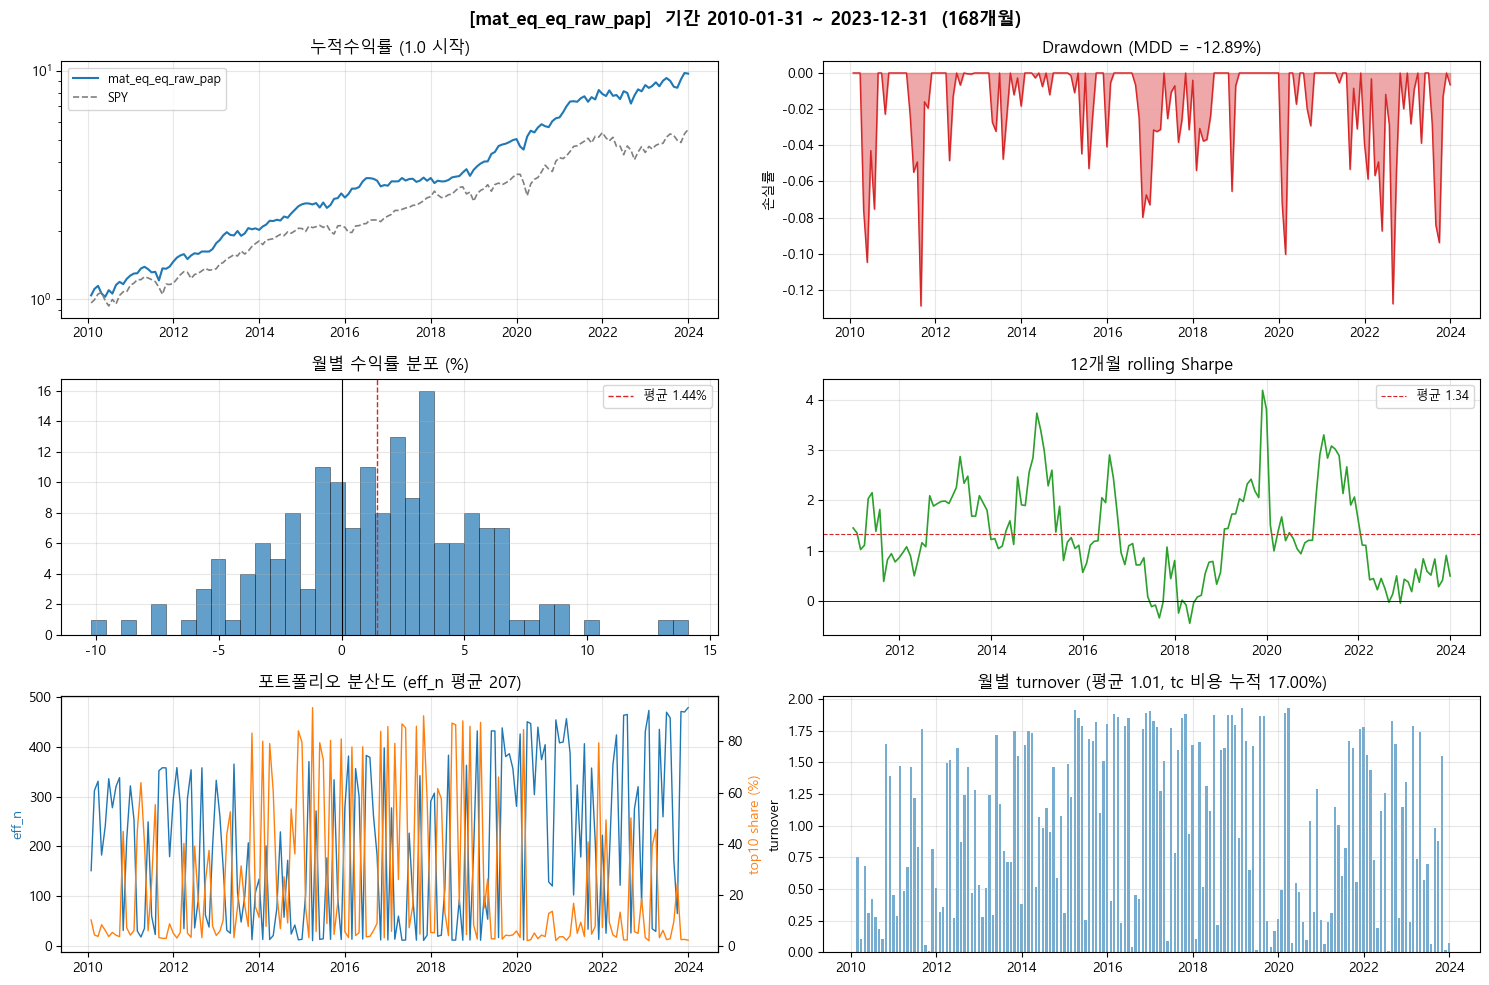


[Config]
  p_mode          = lstm_predicted
  p_weight        = eq
  q_mode          = raw_lam
  q_value         = 0.003
  omega_mode      = ff3_paper
  omega_scale     = 1.0
  prior           = capm_eq
  tc              = 0.001
  max_weight      = 0.1
  lam_mean        = 2.5

[Metrics]
  Sharpe   = 1.185
  Sortino  = 1.996
  CAGR     = 17.66%
  Vol      = 13.83%
  MDD      = -12.89%
  Calmar   = 1.370
  Beta     = -0.185
  Alpha    = 18.72%
  WinRate  = 66.1%


: 

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 예시 1 — 단일 실험 종합 분석
# ────────────────────────────────────────────────────────────────────
name   = 'mat_eq_eq_raw_pap'        # ← 다른 실험 보려면 이 줄만 변경
period = ('2010-01', '2023-12')           # ← 기간 변경 가능 (예: ('2013-01', '2024-12'))

plot_single(name, period=period)

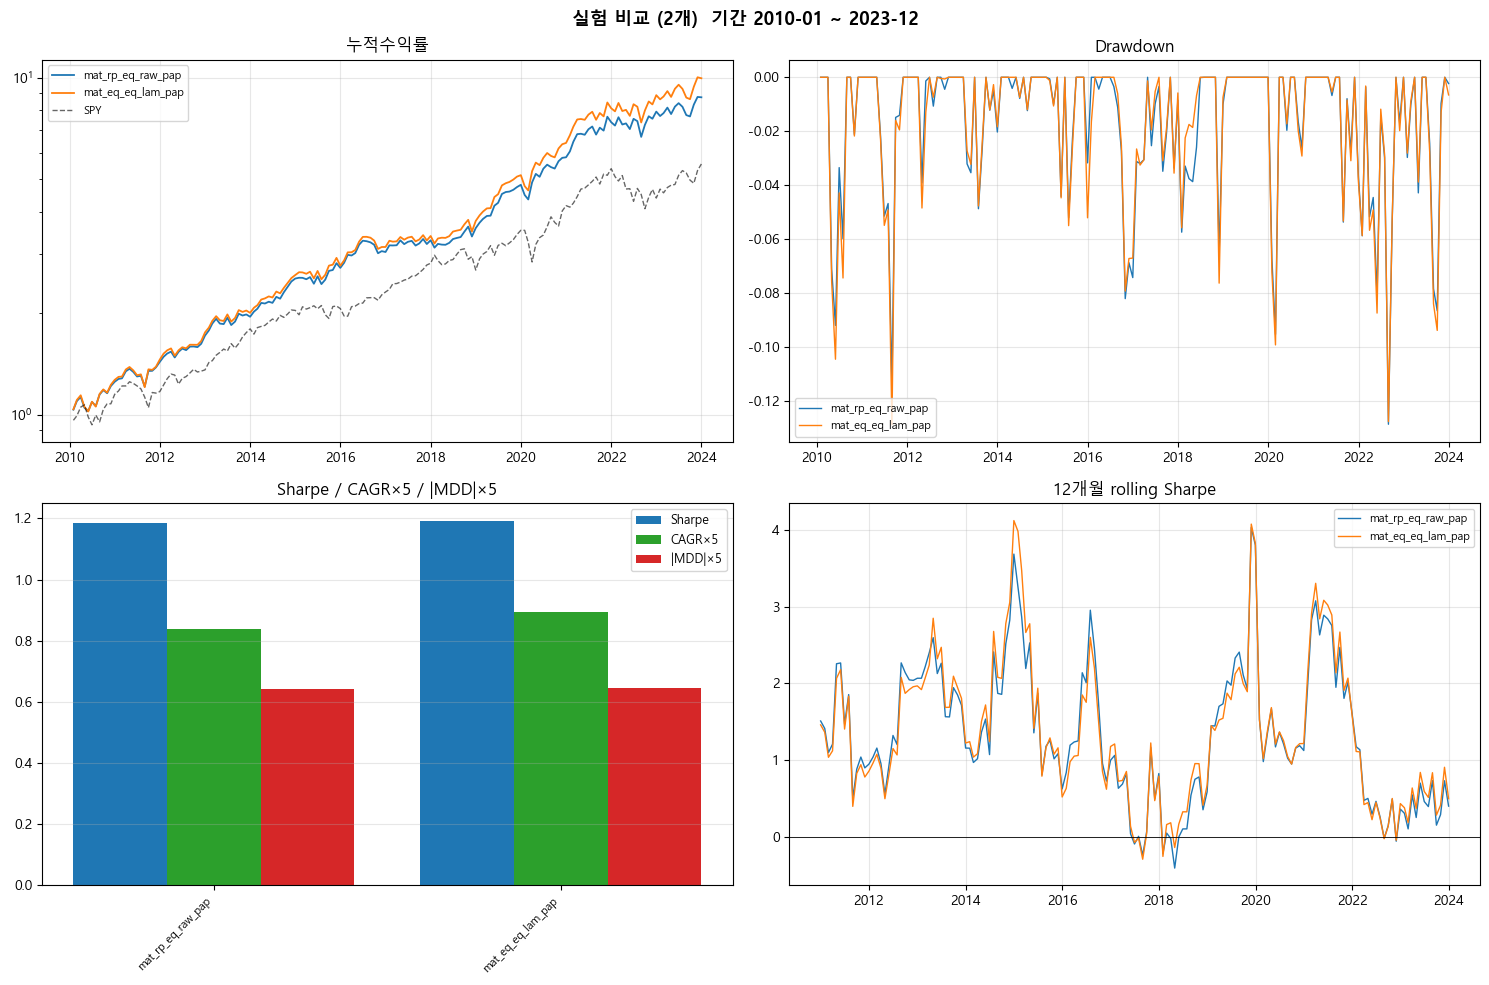


[Metrics 표]
             name  n_month  Sharpe  Sortino   CAGR    Vol     MDD  Calmar   Beta  Alpha WinRate
mat_rp_eq_raw_pap      168   1.185    2.009 16.76% 13.08% -12.87%   1.302 -0.170 17.65%  65.50%
mat_eq_eq_lam_pap      168   1.190    1.978 17.85% 13.92% -12.89%   1.385 -0.194 19.00%  67.30%


In [33]:
# ────────────────────────────────────────────────────────────────────
# 예시 2 — 여러 실험 비교 (vol_mcap vs mcap, lo vs std)
# ────────────────────────────────────────────────────────────────────
names = [
    'mat_rp_eq_raw_pap',
    'mat_eq_eq_lam_pap'
]

plot_compare(names, period=('2010-01', '2023-12'))

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 예시 3 — EWMA omega 동작 진단
# ────────────────────────────────────────────────────────────────────
name = 'p_lstm_vol_mcap_ewma_lo'           # ← 다른 EWMA 실험 가능

plot_omega(name, period=('2010-01', '2024-12'))

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 예시 4 — 가중치 heatmap
# ────────────────────────────────────────────────────────────────────
name = 'p_lstm_vol_mcap_ewma_lo'

plot_weights(name, n_top=20)

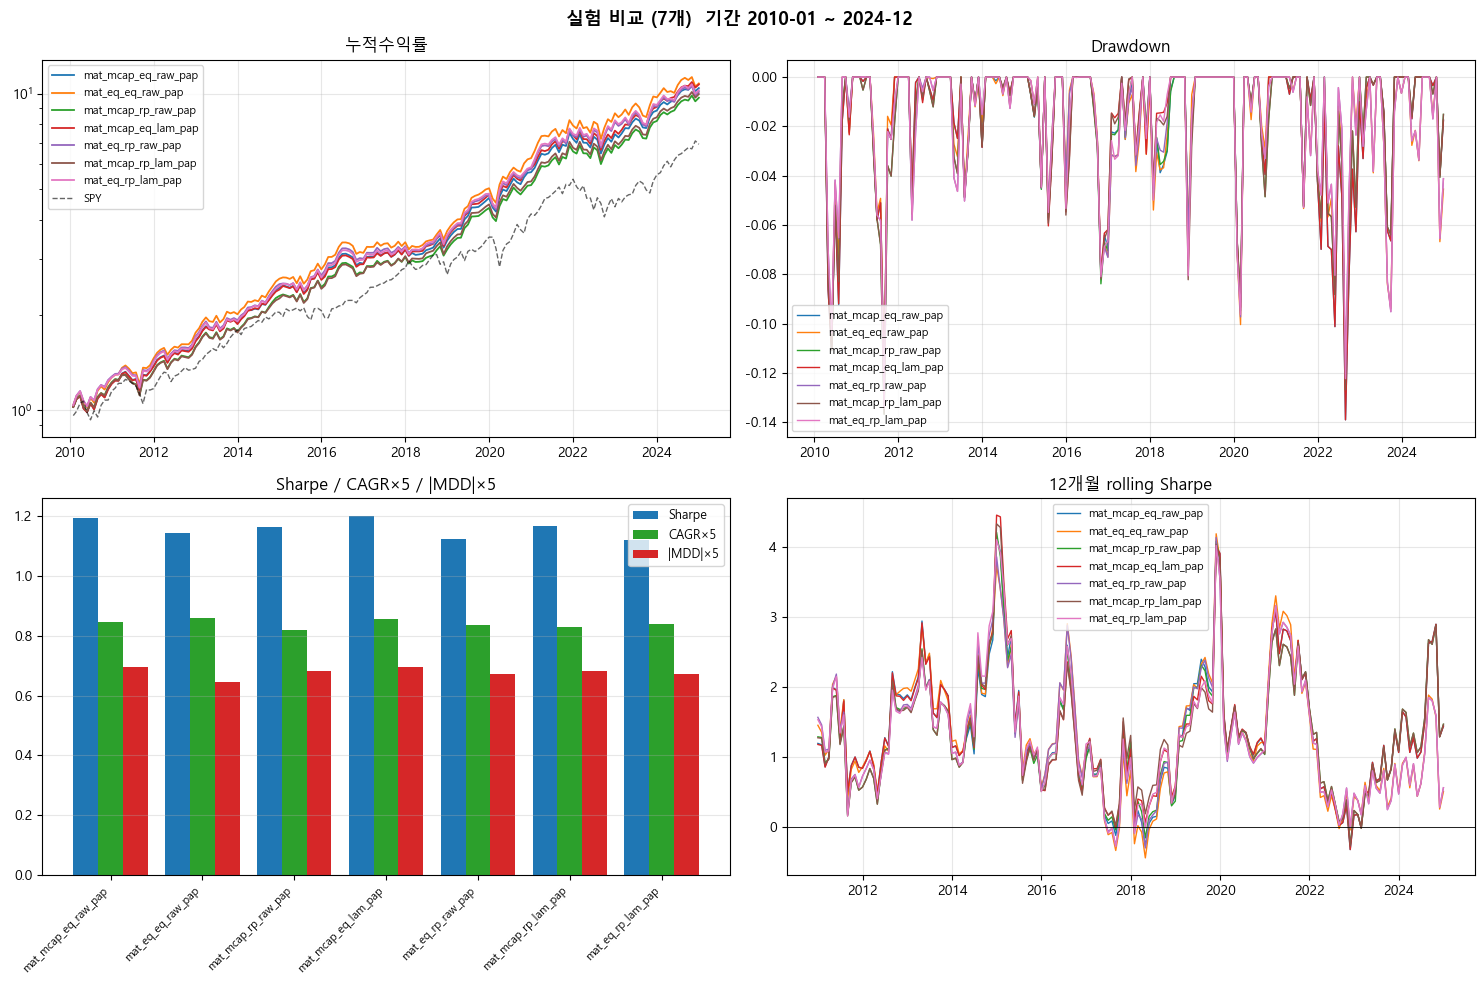


[Metrics 표]
               name  n_month  Sharpe  Sortino   CAGR    Vol     MDD  Calmar   Beta  Alpha WinRate
mat_mcap_eq_raw_pap      180   1.195    1.935 16.92% 12.86% -13.90%   1.217 -0.167 17.52%  66.10%
  mat_eq_eq_raw_pap      180   1.145    1.919 17.18% 13.70% -12.89%   1.333 -0.192 18.18%  66.10%
mat_mcap_rp_raw_pap      180   1.164    1.900 16.37% 12.80% -13.67%   1.197 -0.160 16.95%  66.10%
mat_mcap_eq_lam_pap      180   1.201    1.896 17.12% 12.95% -13.90%   1.232 -0.175 17.81%  67.80%
  mat_eq_rp_raw_pap      180   1.124    1.869 16.70% 13.58% -13.43%   1.243 -0.182 17.62%  65.60%
mat_mcap_rp_lam_pap      180   1.168    1.865 16.58% 12.91% -13.67%   1.213 -0.168 17.25%  66.10%
  mat_eq_rp_lam_pap      180   1.121    1.848 16.80% 13.70% -13.43%   1.250 -0.192 17.85%  66.70%


In [10]:
# ────────────────────────────────────────────────────────────────────
# 예시 5 — omega 변형 모두 비교 (옵션1·옵션2·EWMA × baseline)
# ────────────────────────────────────────────────────────────────────
names = [
    'mat_mcap_eq_raw_pap',
    'mat_eq_eq_raw_pap',
    'mat_mcap_rp_raw_pap',
    'mat_mcap_eq_lam_pap',
    'mat_eq_rp_raw_pap',
    'mat_mcap_rp_lam_pap',
    'mat_eq_rp_lam_pap'
]

plot_compare(names, period=('2010-01', '2024-12'))

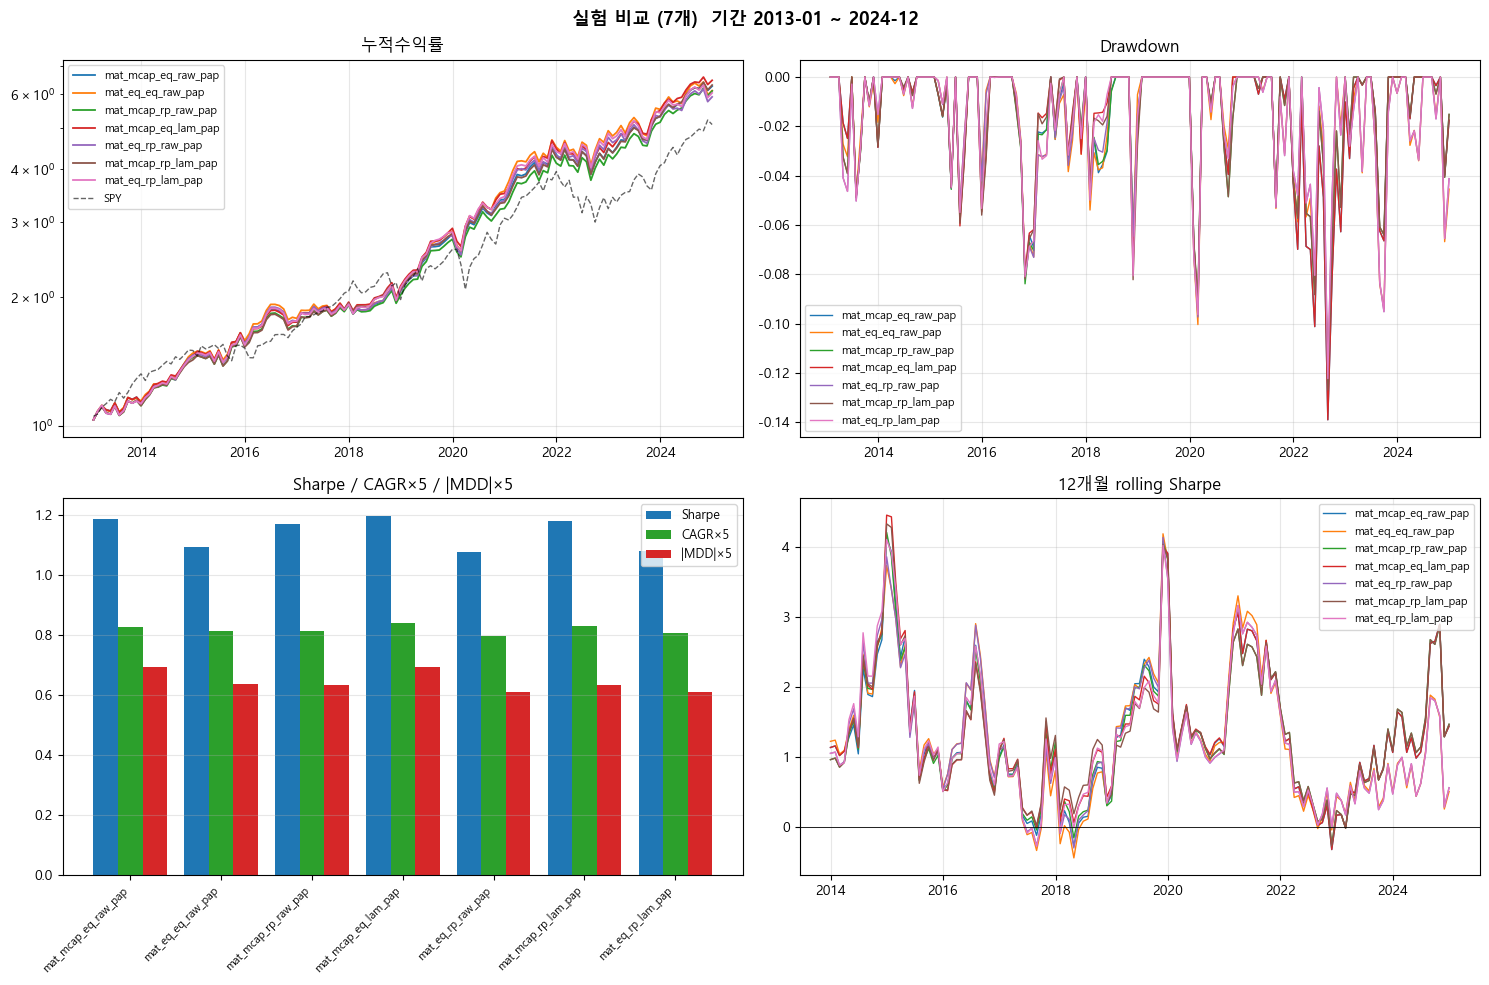


[Metrics 표]
               name  n_month  Sharpe  Sortino   CAGR    Vol     MDD  Calmar   Beta  Alpha WinRate
mat_mcap_eq_raw_pap      144   1.187    1.939 16.53% 12.38% -13.90%   1.189 -0.184 17.15%  66.70%
  mat_eq_eq_raw_pap      144   1.094    1.845 16.30% 13.35% -12.77%   1.277 -0.218 17.51%  66.00%
mat_mcap_rp_raw_pap      144   1.172    1.905 16.28% 12.36% -12.69%   1.283 -0.183 16.90%  67.40%
mat_mcap_eq_lam_pap      144   1.198    1.888 16.84% 12.51% -13.90%   1.211 -0.195 17.57%  68.80%
  mat_eq_rp_raw_pap      144   1.079    1.796 15.97% 13.26% -12.23%   1.306 -0.212 17.14%  65.30%
mat_mcap_rp_lam_pap      144   1.180    1.859 16.59% 12.52% -12.69%   1.307 -0.193 17.33%  67.40%
  mat_eq_rp_lam_pap      144   1.081    1.776 16.17% 13.43% -12.23%   1.323 -0.225 17.51%  66.70%


In [11]:
# ────────────────────────────────────────────────────────────────────
# 예시 6 — 시나리오별 trim 비교 (시나리오 2: 144M)
# ────────────────────────────────────────────────────────────────────
names = [
    'mat_mcap_eq_raw_pap',
    'mat_eq_eq_raw_pap',
    'mat_mcap_rp_raw_pap',
    'mat_mcap_eq_lam_pap',
    'mat_eq_rp_raw_pap',
    'mat_mcap_rp_lam_pap',
    'mat_eq_rp_lam_pap'
]

# 시나리오 2 (λ=0.94) 의 워밍업 36개월 trim 후 비교
plot_compare(names, period=('2013-01', '2024-12'))

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 예시 7 — 전체 metrics 표 (Sharpe 순)
# ────────────────────────────────────────────────────────────────────
all_names = list_results()
df = metrics_summary(all_names, period=('2010-01', '2024-12'))
df_sorted = df.sort_values('Sharpe', ascending=False)

# 표시 포맷
fmt = df_sorted.copy()
for col in ['CAGR', 'Vol', 'MDD', 'Alpha', 'WinRate']:
    fmt[col] = fmt[col].apply(
        lambda x: f'{x*100:.2f}%' if isinstance(x, (int, float)) and not pd.isna(x) else 'N/A')
for col in ['Sharpe', 'Sortino', 'Calmar', 'Beta']:
    fmt[col] = fmt[col].apply(
        lambda x: f'{x:.3f}' if isinstance(x, (int, float)) and not pd.isna(x) else 'N/A')

print(fmt.to_string(index=False))

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 예시 8 — 자유 탐색 (목적별 그룹 비교)
# ────────────────────────────────────────────────────────────────────
# (a) p_weight 효과만 비교 (omega 동일)
names_a = ['p_lstm_mcap', 'p_lstm_eq', 'p_lstm_rp', 'p_lstm_vol_mcap']
plot_compare(names_a, period=('2010-01', '2024-12'))

# (b) prior 효과만 비교
# names_b = ['baseline', 'prior_eq', 'prior_rp_p_mcap']
# plot_compare(names_b)

# (c) BL 없음 비교군
# names_c = ['baseline', 'capm_no_bl', 'naive_lowvol', 'naive_lowvol_rp']
# plot_compare(names_c)